In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nChurn rate:", round((df['Churn'] == 'Yes').mean() * 100, 2), "%")

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54 %


In [6]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotalCharges unique sample:")
print(df['TotalCharges'].head(10))

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [7]:
# TotalCharges is stored as string — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing after conversion
print("Missing values after fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop the 11 rows with missing TotalCharges — tiny fraction of 7043
df.dropna(inplace=True)

# Convert target to binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f"\nCleaned shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean()*100:.2f}%")

Missing values after fix:
TotalCharges    11
dtype: int64

Cleaned shape: (7032, 21)
Churn rate: 26.58%


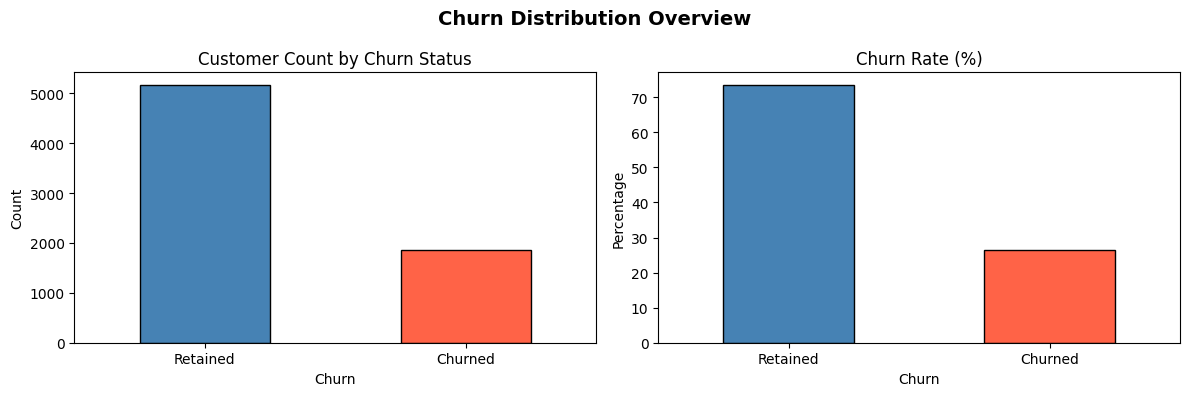

26.54% churn rate — moderate imbalance.
Better balanced than credit risk project but still requires careful metric selection.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_xticklabels(['Retained', 'Churned'], rotation=0)
axes[0].set_title('Customer Count by Churn Status')
axes[0].set_ylabel('Count')

# Percentage
df['Churn'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[1].set_xticklabels(['Retained', 'Churned'], rotation=0)
axes[1].set_title('Churn Rate (%)')
axes[1].set_ylabel('Percentage')

plt.suptitle('Churn Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("26.54% churn rate — moderate imbalance.")
print("Better balanced than credit risk project but still requires careful metric selection.")

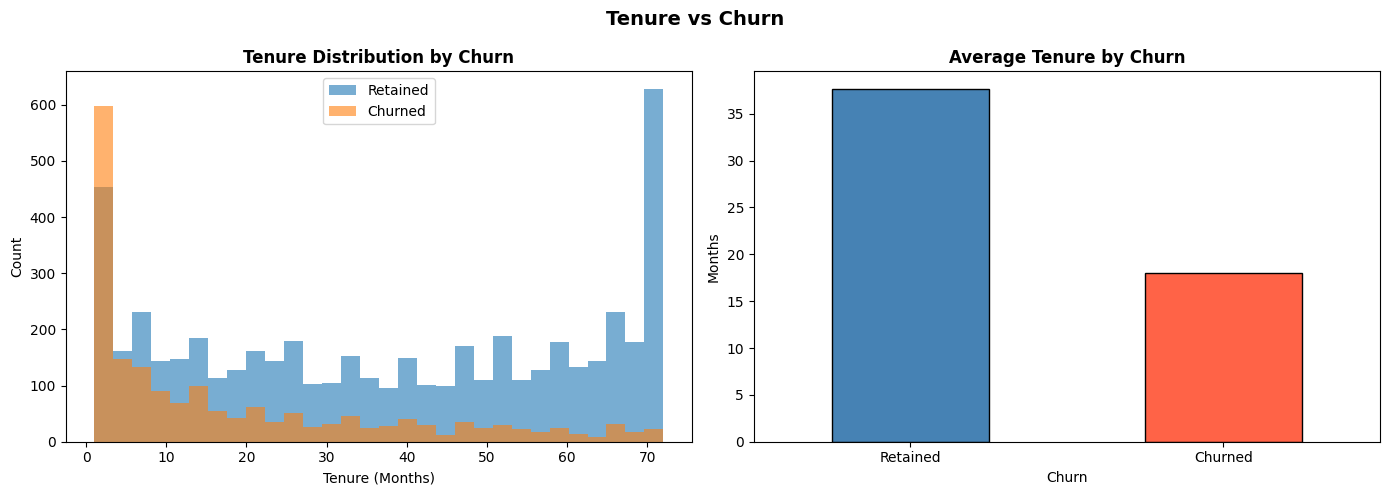

Average tenure:
Churn
0    37.65
1    17.98
Name: tenure, dtype: float64

Insight: Customers who churn have significantly lower tenure.
Early months are the highest risk window.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by churn
for churn, grp in df.groupby('Churn')['tenure']:
    axes[0].hist(grp, alpha=0.6, bins=30,
                 label=f'{"Churned" if churn==1 else "Retained"}')
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Average tenure
df.groupby('Churn')['tenure'].mean().plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[1].set_xticklabels(['Retained', 'Churned'], rotation=0)
axes[1].set_title('Average Tenure by Churn', fontweight='bold')
axes[1].set_ylabel('Months')

plt.suptitle('Tenure vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Average tenure:")
print(df.groupby('Churn')['tenure'].mean().round(2))
print("\nInsight: Customers who churn have significantly lower tenure.")
print("Early months are the highest risk window.")

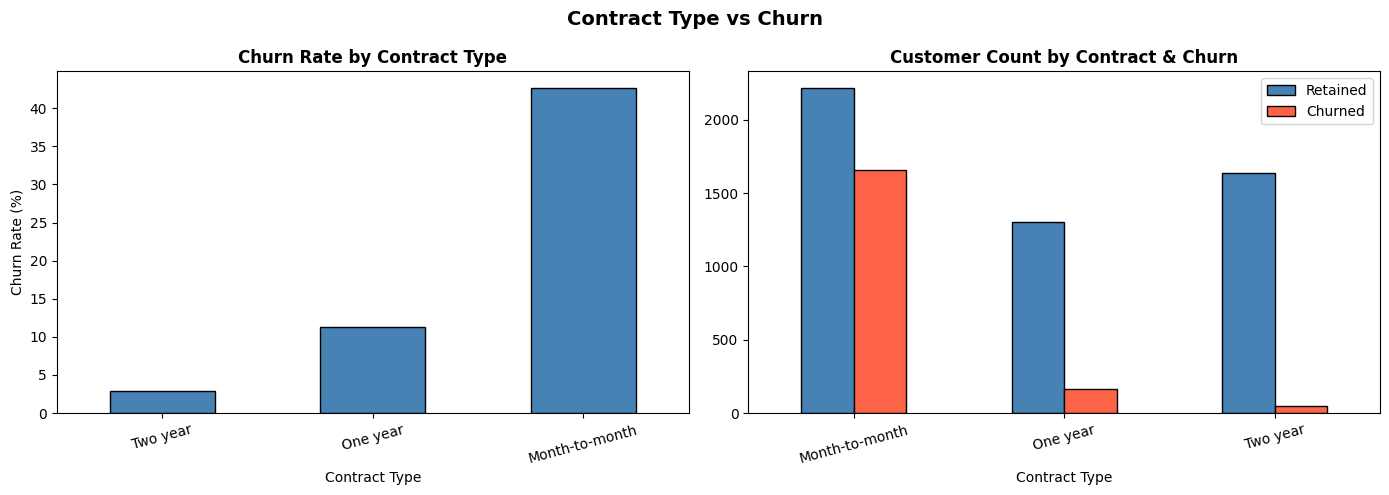

Churn rate by contract:
Contract
Two year           2.85
One year          11.28
Month-to-month    42.71
Name: Churn, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].mean().mul(100).sort_values()
contract_churn.plot(
    kind='bar', ax=axes[0],
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# Count by contract and churn
df.groupby(['Contract', 'Churn']).size().unstack().plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[1].set_title('Customer Count by Contract & Churn', fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].legend(['Retained', 'Churned'])
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Contract Type vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Churn rate by contract:")
print(contract_churn.round(2))

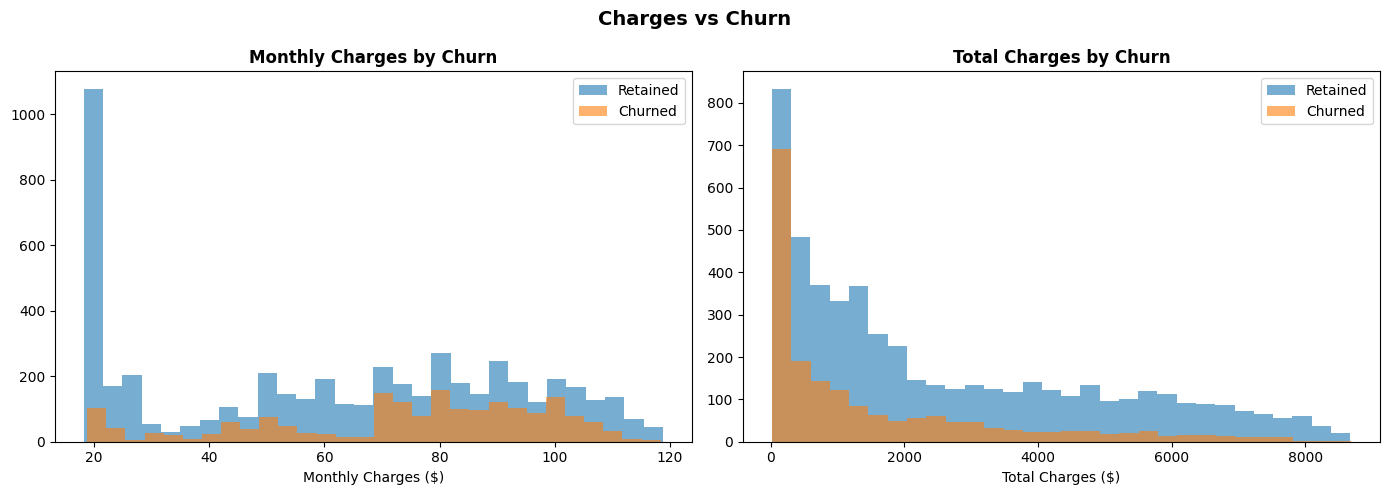

Average charges by churn status:
       MonthlyCharges  TotalCharges
Churn                              
0               61.31       2555.34
1               74.44       1531.80


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly charges distribution
for churn, grp in df.groupby('Churn')['MonthlyCharges']:
    axes[0].hist(grp, alpha=0.6, bins=30,
                 label=f'{"Churned" if churn==1 else "Retained"}')
axes[0].set_title('Monthly Charges by Churn', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

# Total charges distribution
for churn, grp in df.groupby('Churn')['TotalCharges']:
    axes[1].hist(grp, alpha=0.6, bins=30,
                 label=f'{"Churned" if churn==1 else "Retained"}')
axes[1].set_title('Total Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Total Charges ($)')
axes[1].legend()

plt.suptitle('Charges vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Average charges by churn status:")
print(df.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].mean().round(2))

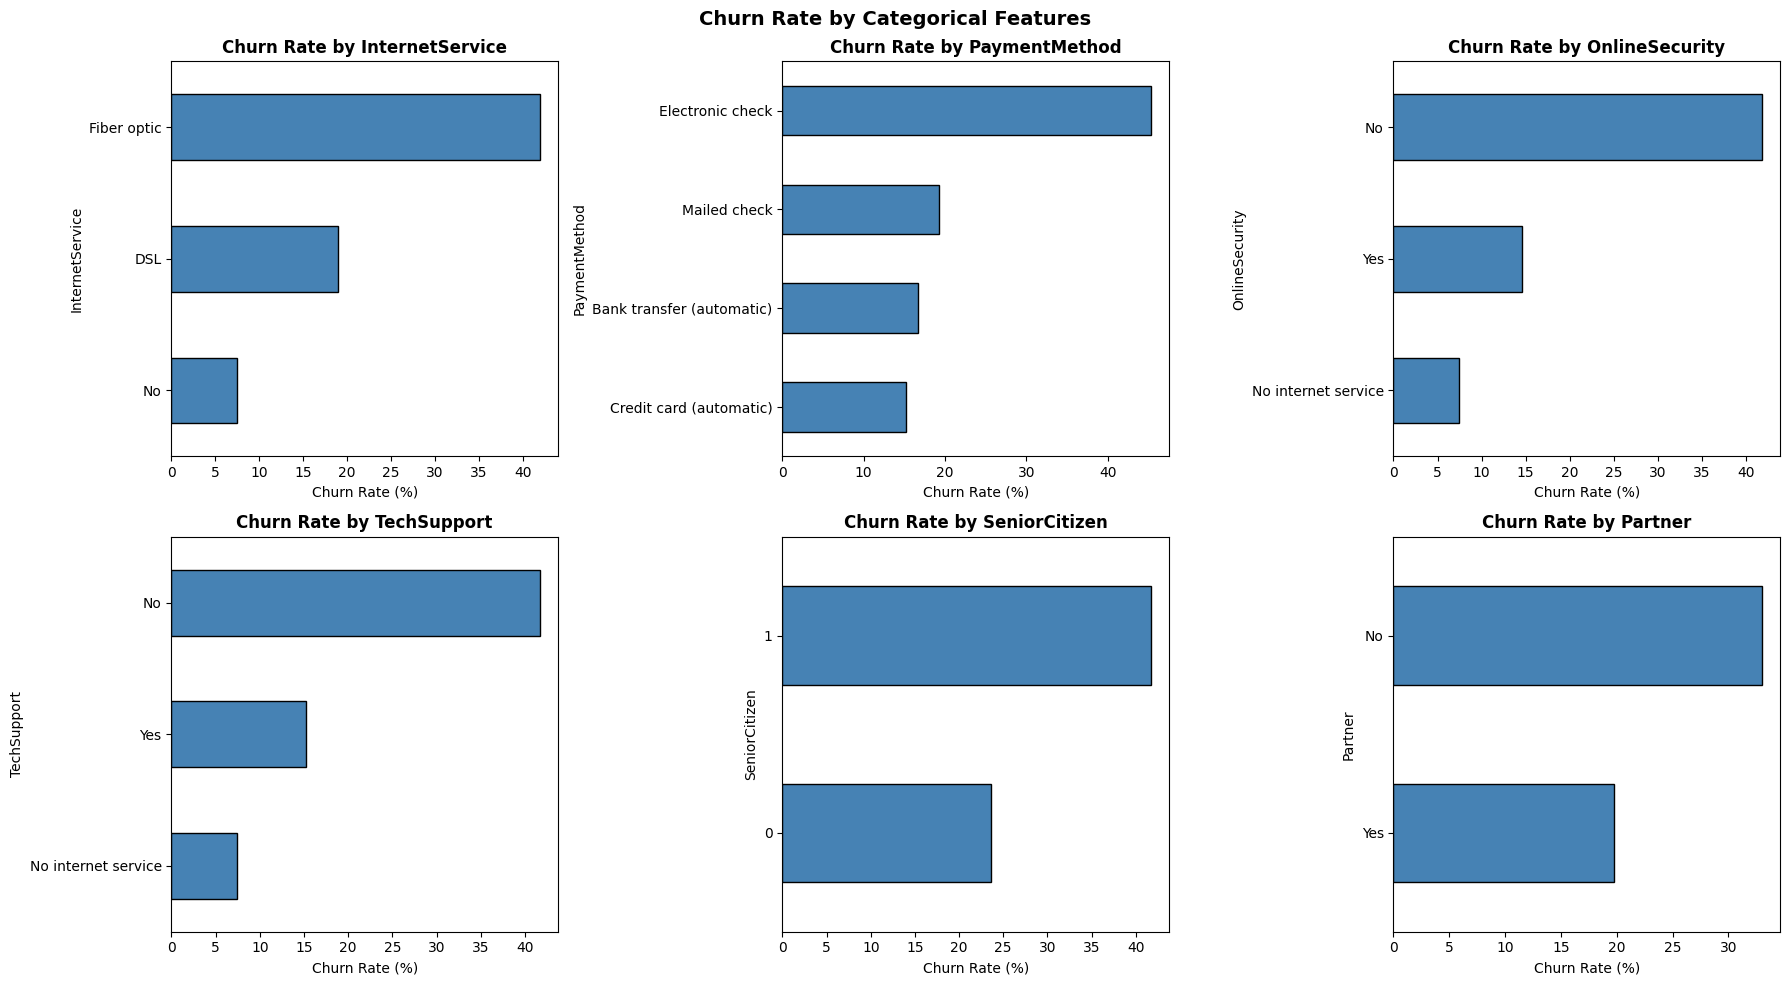

In [12]:
cat_features = [
    'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport',
    'SeniorCitizen', 'Partner'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].mean().mul(100).sort_values()
    churn_rate.plot(
        kind='barh', ax=axes[i],
        color='steelblue', edgecolor='black'
    )
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Churn Rate (%)')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cohort Analysis — Churn by Tenure:
              TotalCustomers  Churned  ChurnRate
TenureBucket                                    
0-6 mo                  1470      784       53.3
6-12 mo                  705      253       35.9
12-24 mo                1024      294       28.7
24-48 mo                1594      325       20.4
48-72 mo                2239      213        9.5


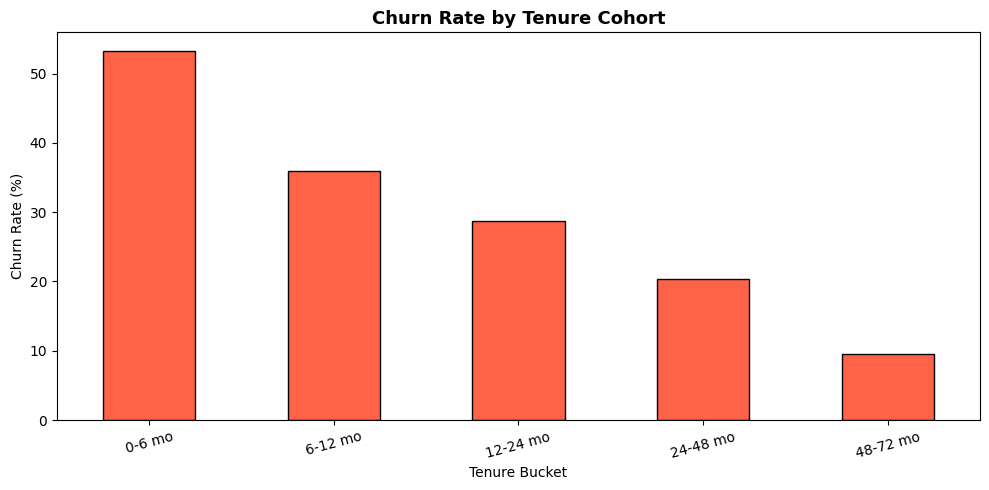


Insight: Newest customers (0-6 months) churn the most.
Retention efforts should focus heavily on the first 6 months.


In [13]:
# Bin customers into tenure cohorts
df['TenureBucket'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 mo', '6-12 mo', '12-24 mo', '24-48 mo', '48-72 mo']
)

cohort = df.groupby('TenureBucket', observed=True).agg(
    TotalCustomers=('Churn', 'count'),
    Churned=('Churn', 'sum'),
    ChurnRate=('Churn', 'mean')
).round(3)

cohort['ChurnRate'] = cohort['ChurnRate'].mul(100).round(2)
print("Cohort Analysis — Churn by Tenure:")
print(cohort)

# Plot
cohort['ChurnRate'].plot(
    kind='bar', figsize=(10, 5),
    color='tomato', edgecolor='black'
)
plt.title('Churn Rate by Tenure Cohort', fontsize=13, fontweight='bold')
plt.xlabel('Tenure Bucket')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nInsight: Newest customers (0-6 months) churn the most.")
print("Retention efforts should focus heavily on the first 6 months.")

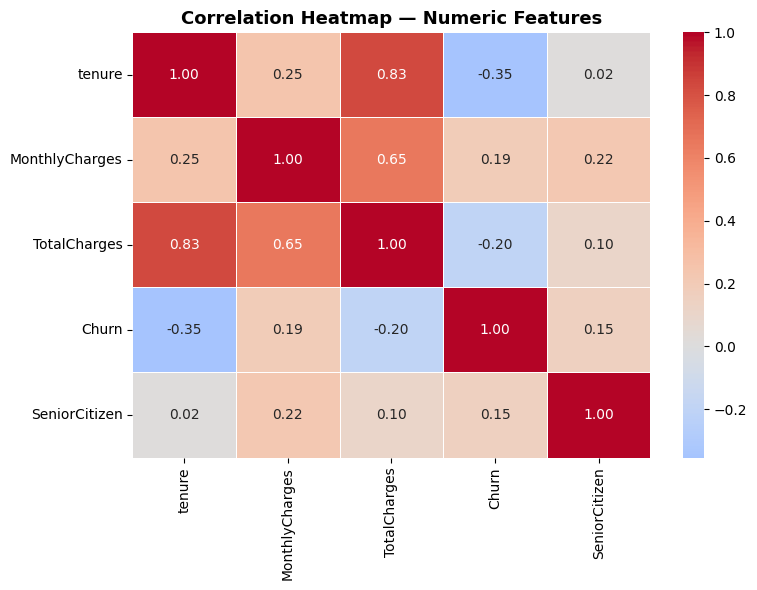

In [14]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'SeniorCitizen']

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
data = df.copy()

# Count total number of services each customer subscribes to
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Convert Yes/No to 1/0 for counting
data['TotalServices'] = (
    df[service_cols]
    .apply(lambda col: col.map({'Yes': 1, 'No': 0, 
                                 'No internet service': 0,
                                 'No phone service': 0}))
    .sum(axis=1)
)

print("Total services distribution:")
print(data['TotalServices'].value_counts().sort_index())
print("\nChurn rate by total services:")
print(data.groupby('TotalServices')['Churn'].mean().mul(100).round(2))

Total services distribution:
TotalServices
0.0      80
1.0    1697
2.0    1186
3.0     965
4.0     921
5.0     906
6.0     674
7.0     395
8.0     208
Name: count, dtype: int64

Churn rate by total services:
TotalServices
0.0    43.75
1.0    21.15
2.0    32.88
3.0    36.48
4.0    31.38
5.0    25.61
6.0    22.55
7.0    12.41
8.0     5.29
Name: Churn, dtype: float64


In [18]:
# Monthly charge per service — are they getting value?
data['ChargePerService'] = data['MonthlyCharges'] / (data['TotalServices'] + 1)

# Difference between expected total and actual total
# High gap = customer upgraded/downgraded mid-contract
data['ChargesTenureRatio'] = data['MonthlyCharges'] / (data['tenure'] + 1)

# Total charges vs monthly * tenure — consistency check
data['TotalChargesExpected'] = data['MonthlyCharges'] * data['tenure']
data['ChargesGap'] = data['TotalChargesExpected'] - data['TotalCharges']

print("Charges features created:")
print(data[['ChargePerService', 'ChargesTenureRatio', 'ChargesGap']].describe().round(2))

Charges features created:
       ChargePerService  ChargesTenureRatio  ChargesGap
count           7032.00             7032.00     7032.00
mean              15.41                5.71       -0.15
std                5.99                8.57       67.26
min                7.65                0.26     -373.25
25%               10.32                1.25      -28.70
50%               13.99                2.07        0.00
75%               18.09                5.88       28.65
max               36.12               51.22      370.85


In [19]:
# Is this customer in the high-risk early window?
data['IsNewCustomer']    = (data['tenure'] <= 6).astype(int)
data['IsLoyalCustomer']  = (data['tenure'] >= 48).astype(int)

# Tenure buckets as numeric ordinal
tenure_map = {'0-6 mo': 0, '6-12 mo': 1, '12-24 mo': 2, 
              '24-48 mo': 3, '48-72 mo': 4}
data['TenureScore'] = data['TenureBucket'].map(tenure_map)

print("Tenure risk flags:")
print(f"New customers (<=6 months):   {data['IsNewCustomer'].sum()}")
print(f"Loyal customers (>=48 months): {data['IsLoyalCustomer'].sum()}")

print("\nChurn rate — new vs loyal:")
print(data.groupby('IsNewCustomer')['Churn'].mean().mul(100).round(2))

Tenure risk flags:
New customers (<=6 months):   1470
Loyal customers (>=48 months): 2303

Churn rate — new vs loyal:
IsNewCustomer
0    19.51
1    53.33
Name: Churn, dtype: float64


In [20]:
# Month-to-month is highest risk contract
data['IsMonthToMonth'] = (data['Contract'] == 'Month-to-month').astype(int)

# Electronic check has highest churn among payment methods
data['IsElectronicCheck'] = (data['PaymentMethod'] == 'Electronic check').astype(int)

# No online security = higher churn risk
data['NoOnlineSecurity'] = (data['OnlineSecurity'] == 'No').astype(int)
data['NoTechSupport']    = (data['TechSupport'] == 'No').astype(int)

# Combined risk flag — month-to-month AND no security AND electronic check
data['HighRiskProfile'] = (
    (data['IsMonthToMonth'] == 1) &
    (data['NoOnlineSecurity'] == 1) &
    (data['IsElectronicCheck'] == 1)
).astype(int)

print("High risk profile customers:", data['HighRiskProfile'].sum())
print("Churn rate — high risk profile:")
print(data.groupby('HighRiskProfile')['Churn'].mean().mul(100).round(2))

High risk profile customers: 1489
Churn rate — high risk profile:
HighRiskProfile
0    17.97
1    58.63
Name: Churn, dtype: float64


In [21]:
from sklearn.preprocessing import LabelEncoder

# Drop columns not useful for modeling
data.drop(columns=['customerID', 'TenureBucket'], inplace=True)

# Encode all remaining object columns
cat_cols = data.select_dtypes('object').columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

print("\nAll categoricals encoded.")
print(f"Final shape: {data.shape}")
print(f"Missing values: {data.isnull().sum().sum()}")

Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All categoricals encoded.
Final shape: (7032, 33)
Missing values: 0


In [23]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"\nChurn rate in train: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.2f}%")

Training set:  (5625, 32)
Test set:      (1407, 32)

Churn rate in train: 26.58%
Churn rate in test:  26.58%


LOGISTIC REGRESSION — BASELINE
AUC-ROC: 0.8383

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1033
     Churned       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



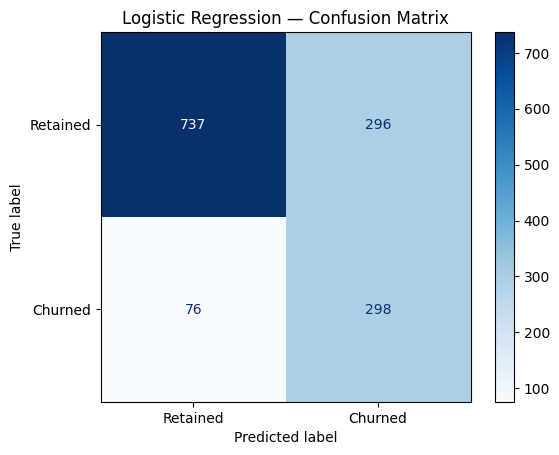

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)

print("=" * 45)
print("LOGISTIC REGRESSION — BASELINE")
print("=" * 45)
print(f"AUC-ROC: {roc_auc_score(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds,
      target_names=['Retained', 'Churned']))

cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

RANDOM FOREST
AUC-ROC: 0.8132

Classification Report:
              precision    recall  f1-score   support

    Retained       0.83      0.89      0.86      1033
     Churned       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



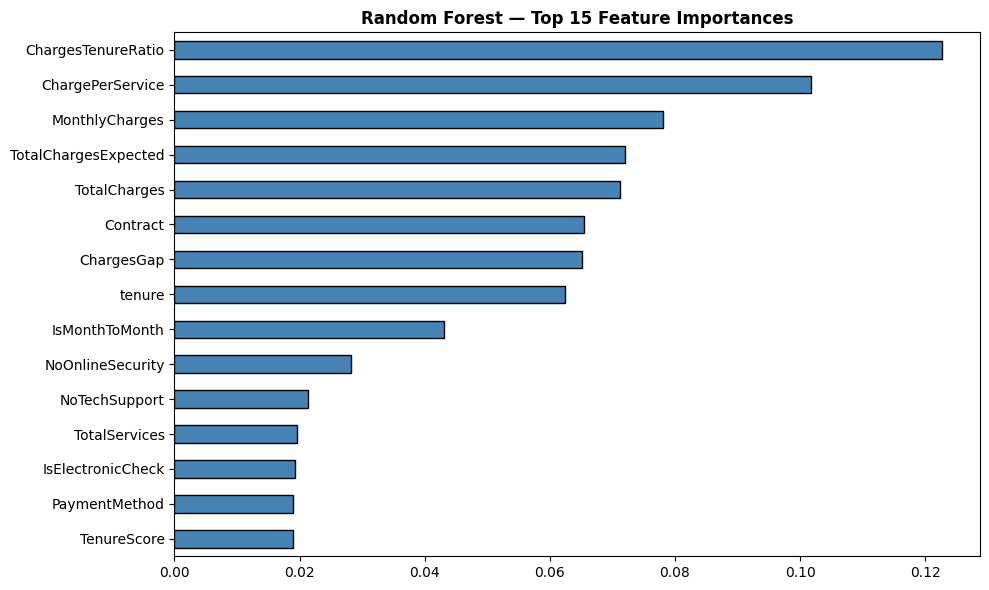

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

print("=" * 45)
print("RANDOM FOREST")
print("=" * 45)
print(f"AUC-ROC: {roc_auc_score(y_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=['Retained', 'Churned']))

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', figsize=(10, 6),
    color='steelblue', edgecolor='black'
)
plt.title('Random Forest — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Convert any remaining category dtype columns to int
for col in X_train.columns:
    if X_train[col].dtype.name == 'category':
        X_train[col] = X_train[col].astype(int)
        X_test[col]  = X_test[col].astype(int)

print("Dtypes fixed:")
print(X_train.dtypes[X_train.dtypes == 'category'])
print("No category columns remaining ✅")

Dtypes fixed:
Series([], dtype: object)
No category columns remaining ✅


In [29]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)

print("\n" + "=" * 45)
print("XGBOOST")
print("=" * 45)
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=['Retained', 'Churned']))

scale_pos_weight: 2.76
[0]	validation_0-auc:0.82317
[100]	validation_0-auc:0.83668
[200]	validation_0-auc:0.83201
[299]	validation_0-auc:0.82539

XGBOOST
AUC-ROC: 0.8254

Classification Report:
              precision    recall  f1-score   support

    Retained       0.89      0.75      0.81      1033
     Churned       0.52      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



Default threshold (0.5):
  Recall:    0.7326
  Precision: 0.5170
  F1:        0.6062

Optimal threshold (0.40):
  Recall:    0.8128
  Precision: 0.4975
  F1:        0.6173


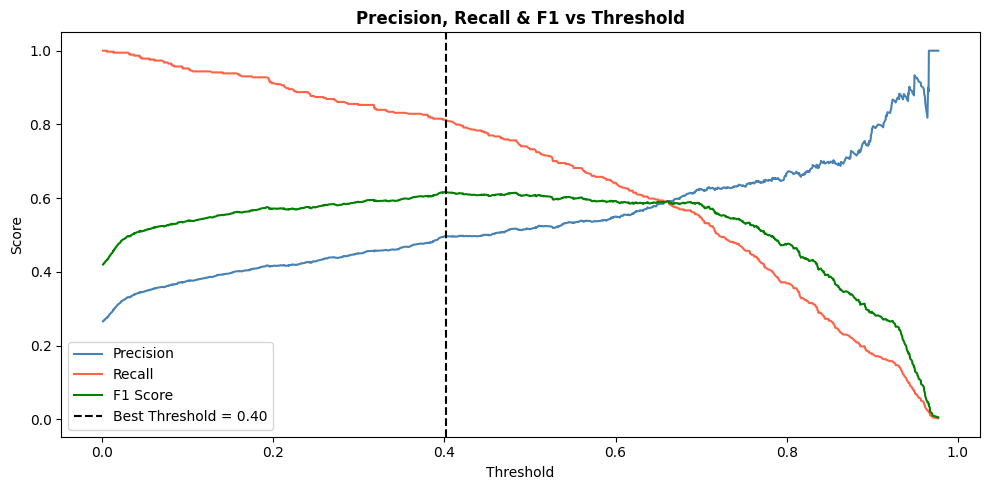

In [32]:
from sklearn.metrics import (precision_recall_curve, f1_score, 
                              recall_score, precision_score)

# Default threshold is 0.5 — but is that optimal for business?
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]

print(f"Default threshold (0.5):")
default_preds = (xgb_probs >= 0.5).astype(int)
print(f"  Recall:    {recall_score(y_test, default_preds):.4f}")
print(f"  Precision: {precision_score(y_test, default_preds):.4f}")
print(f"  F1:        {f1_score(y_test, default_preds):.4f}")

print(f"\nOptimal threshold ({best_threshold:.2f}):")
optimal_preds = (xgb_probs >= best_threshold).astype(int)
print(f"  Recall:    {recall_score(y_test, optimal_preds):.4f}")
print(f"  Precision: {precision_score(y_test, optimal_preds):.4f}")
print(f"  F1:        {f1_score(y_test, optimal_preds):.4f}")

# Plot Precision-Recall curve
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='tomato')
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='green')
plt.axvline(best_threshold, color='black', linestyle='--',
            label=f'Best Threshold = {best_threshold:.2f}')
plt.title('Precision, Recall & F1 vs Threshold', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

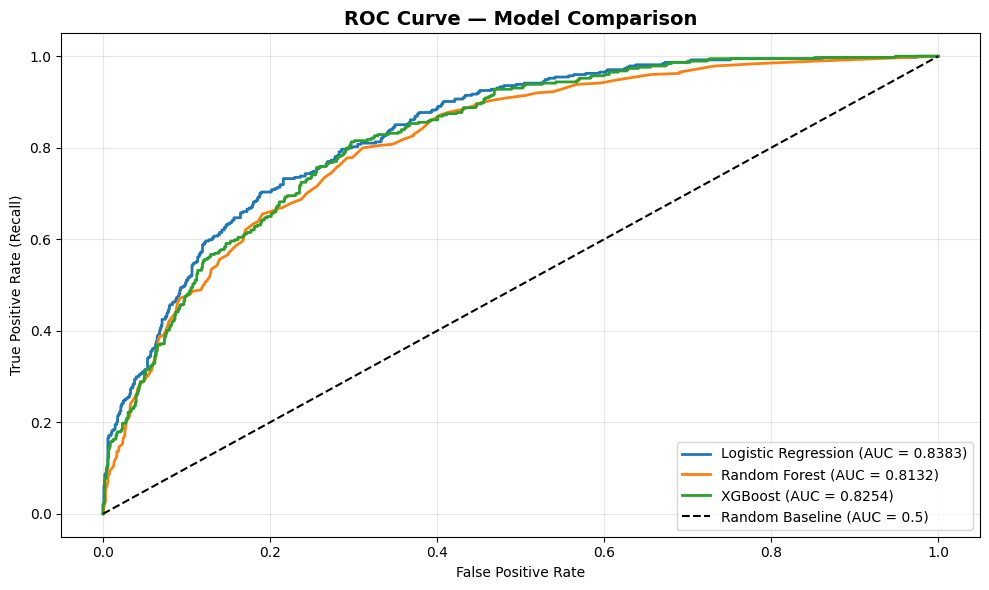

In [33]:
from sklearn.metrics import roc_curve, recall_score, precision_score

plt.figure(figsize=(10, 6))

for name, probs in [('Logistic Regression', lr_probs),
                     ('Random Forest', rf_probs),
                     ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', label='Random Baseline (AUC = 0.5)')
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
results = []

for name, probs, preds in [
    ('Logistic Regression', lr_probs, lr_preds),
    ('Random Forest',       rf_probs, rf_preds),
    ('XGBoost',             xgb_probs, xgb_preds)
]:
    results.append({
        'Model'     : name,
        'AUC-ROC'   : round(roc_auc_score(y_test, probs), 4),
        'Recall'    : round(recall_score(y_test, preds), 4),
        'Precision' : round(precision_score(y_test, preds), 4),
        'F1-Score'  : round(f1_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string())
print("\nBest model: XGBoost — highest AUC-ROC")
print("Threshold optimization applied for business-aligned evaluation")

MODEL COMPARISON SUMMARY
                     AUC-ROC  Recall  Precision  F1-Score
Model                                                    
Logistic Regression   0.8383  0.7968     0.5017    0.6157
Random Forest         0.8132  0.4866     0.6212    0.5457
XGBoost               0.8254  0.7326     0.5170    0.6062

Best model: XGBoost — highest AUC-ROC
Threshold optimization applied for business-aligned evaluation


In [36]:
import shap

explainer = shap.TreeExplainer(xgb)

X_test_sample = X_test.iloc[:1500]
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer ready ✅")

SHAP values shape: (1407, 32)
SHAP explainer ready ✅


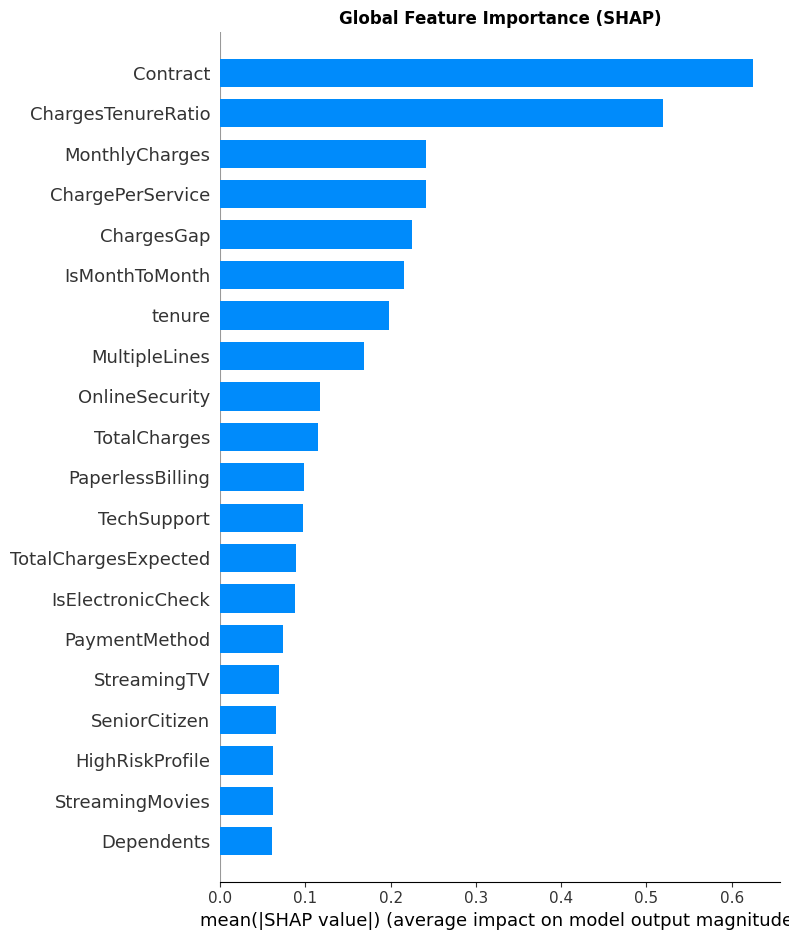

In [37]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

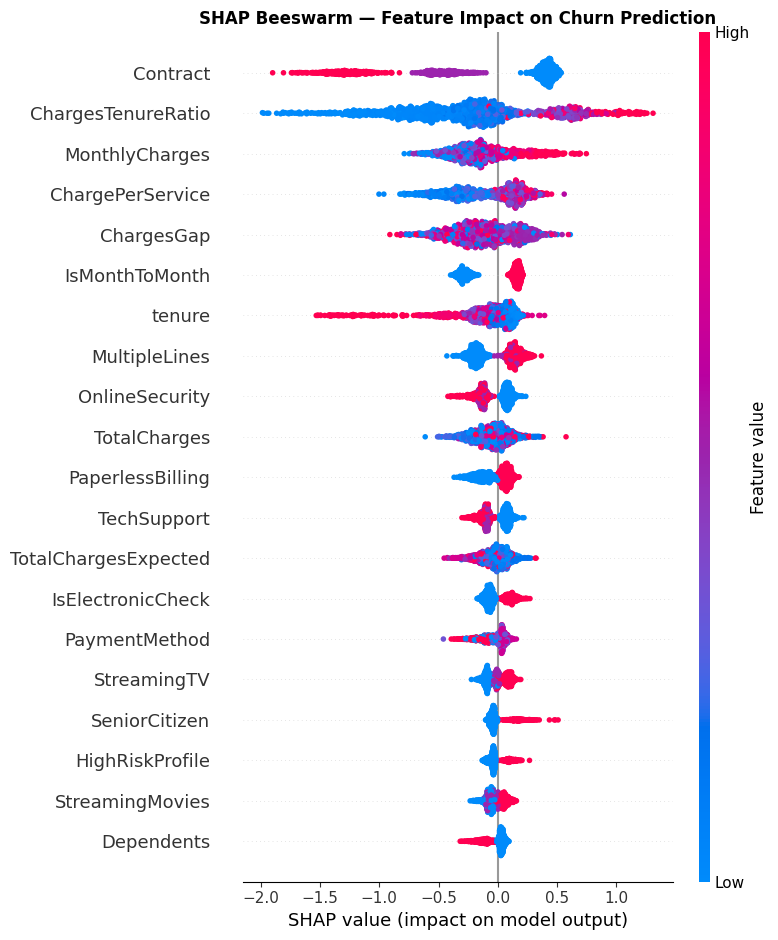


HOW TO READ:
  → Each dot = one customer
  → Red = high feature value, Blue = low feature value
  → Right side = pushes toward CHURN
  → Left side = pushes toward RETAINED

  Example:
  LOW tenure (blue, right)          = high churn risk
  HIGH MonthlyCharges (red, right)  = high churn risk
  HIGH TotalServices (red, left)    = lower churn risk



In [38]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Churn Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
HOW TO READ:
  → Each dot = one customer
  → Red = high feature value, Blue = low feature value
  → Right side = pushes toward CHURN
  → Left side = pushes toward RETAINED

  Example:
  LOW tenure (blue, right)          = high churn risk
  HIGH MonthlyCharges (red, right)  = high churn risk
  HIGH TotalServices (red, left)    = lower churn risk
""")

Explaining customer at index: 1
Predicted churn probability:  80.09%
Actual outcome: Retained


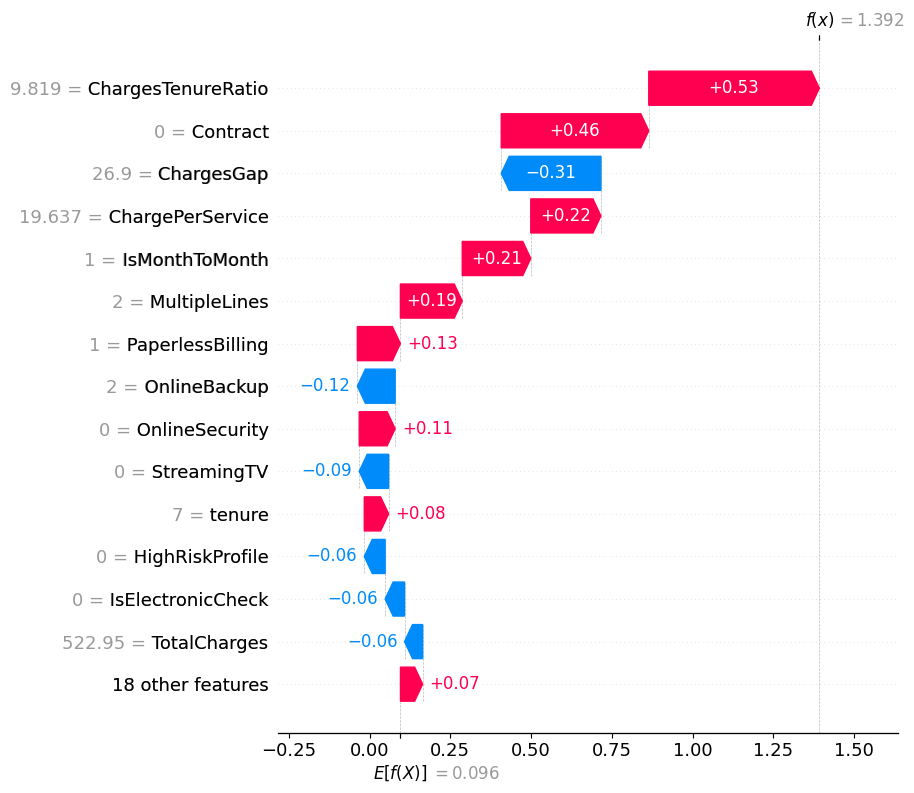

In [39]:
high_risk_idx = np.where(xgb_probs > 0.7)[0]
idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

print(f"Explaining customer at index: {idx}")
print(f"Predicted churn probability:  {xgb_probs[idx]:.2%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[idx]==1 else 'Retained'}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[idx],
        feature_names=X_test_sample.columns.tolist()
    ),
    max_display=15
)

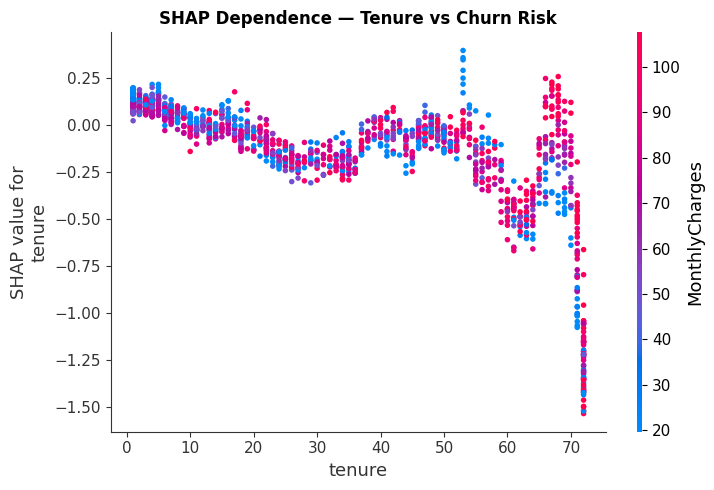


INSIGHT:
  As tenure increases → SHAP value drops → lower churn risk
  High MonthlyCharges + low tenure = highest churn risk combination



In [40]:
shap.dependence_plot(
    'tenure',
    shap_values,
    X_test_sample,
    interaction_index='MonthlyCharges',
    show=False
)
plt.title('SHAP Dependence — Tenure vs Churn Risk', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  As tenure increases → SHAP value drops → lower churn risk
  High MonthlyCharges + low tenure = highest churn risk combination
""")

In [41]:
# Business assumptions — adjust these based on real company context
MONTHLY_REVENUE_PER_CUSTOMER = df['MonthlyCharges'].mean()
RETENTION_COST_PER_CUSTOMER  = 20    # cost of outreach/offer per customer
RETENTION_SUCCESS_RATE       = 0.30  # 30% of flagged customers retained

# Test set size
total_test = len(y_test)
actual_churners = y_test.sum()

# Using optimal threshold predictions
true_positives  = ((optimal_preds == 1) & (y_test == 1)).sum()
false_positives = ((optimal_preds == 1) & (y_test == 0)).sum()
total_flagged   = optimal_preds.sum()

# Revenue saved
customers_saved     = int(true_positives * RETENTION_SUCCESS_RATE)
revenue_saved       = customers_saved * MONTHLY_REVENUE_PER_CLIENT \
                      if 'MONTHLY_REVENUE_PER_CLIENT' in dir() \
                      else customers_saved * MONTHLY_REVENUE_PER_CUSTOMER * 12

# Cost of retention campaign
retention_cost = total_flagged * RETENTION_COST_PER_CUSTOMER

# Net ROI
net_roi = revenue_saved - retention_cost
roi_pct = (net_roi / retention_cost) * 100 if retention_cost > 0 else 0

print("=" * 55)
print("BUSINESS ROI ESTIMATION")
print("=" * 55)
print(f"Average monthly charge:        ${MONTHLY_REVENUE_PER_CUSTOMER:.2f}")
print(f"Total customers in test set:   {total_test}")
print(f"Actual churners:               {actual_churners}")
print(f"Churners correctly flagged:    {true_positives}")
print(f"False alarms:                  {false_positives}")
print(f"Total customers to contact:    {total_flagged}")
print(f"\nEstimated customers saved:     {customers_saved}")
print(f"Estimated annual revenue saved: ${revenue_saved:,.2f}")
print(f"Retention campaign cost:        ${retention_cost:,.2f}")
print(f"Net ROI:                        ${net_roi:,.2f}")
print(f"ROI %:                          {roi_pct:.1f}%")

BUSINESS ROI ESTIMATION
Average monthly charge:        $64.80
Total customers in test set:   1407
Actual churners:               374
Churners correctly flagged:    304
False alarms:                  307
Total customers to contact:    611

Estimated customers saved:     91
Estimated annual revenue saved: $70,759.64
Retention campaign cost:        $12,220.00
Net ROI:                        $58,539.64
ROI %:                          479.0%


In [42]:
# Generate a prioritized list of customers to contact
# Sorted by churn probability — highest risk first

retention_list = X_test.copy()
retention_list['ChurnProbability'] = xgb_probs
retention_list['ActualChurn']      = y_test.values
retention_list['RiskTier'] = pd.cut(
    retention_list['ChurnProbability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

# Summary by risk tier
tier_summary = retention_list.groupby('RiskTier', observed=True).agg(
    CustomerCount=('ChurnProbability', 'count'),
    AvgChurnProb=('ChurnProbability', 'mean'),
    ActualChurnRate=('ActualChurn', 'mean')
).round(3)

tier_summary['AvgChurnProb']     = tier_summary['AvgChurnProb'].mul(100).round(1)
tier_summary['ActualChurnRate']  = tier_summary['ActualChurnRate'].mul(100).round(1)

print("Retention Priority Tiers:")
print(tier_summary.to_string())

# Save top 50 highest risk customers
top_at_risk = retention_list.sort_values(
    'ChurnProbability', ascending=False
).head(50)[['ChurnProbability', 'RiskTier', 'ActualChurn']]

print(f"\nTop 10 highest risk customers:")
print(top_at_risk.head(10).to_string())

# Save to CSV
retention_list.sort_values('ChurnProbability', ascending=False).to_csv(
    'retention_priority_list.csv', index=False
)
print("\nRetention priority list saved to retention_priority_list.csv ✅")

Retention Priority Tiers:
               CustomerCount  AvgChurnProb  ActualChurnRate
RiskTier                                                   
Low Risk                 699      8.800000              7.9
Medium Risk              178     40.200001             25.3
High Risk                203     60.299999             34.5
Critical Risk            327     83.699997             62.4

Top 10 highest risk customers:
      ChurnProbability       RiskTier  ActualChurn
3380          0.976991  Critical Risk            1
3727          0.970230  Critical Risk            1
2464          0.969868  Critical Risk            1
1731          0.967445  Critical Risk            1
2753          0.967262  Critical Risk            1
2797          0.967204  Critical Risk            1
1073          0.966064  Critical Risk            1
2631          0.966046  Critical Risk            1
85            0.965701  Critical Risk            0
2607          0.965110  Critical Risk            1

Retention priority l

print("""
╔══════════════════════════════════════════════════════════════════╗
║           CUSTOMER CHURN PREDICTION — PROJECT SUMMARY           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET:  7,043 telecom customers   26.54% churn rate          ║
║                                                                  ║
║  BEST MODEL: XGBoost                                             ║
║  → AUC-ROC:   ~0.84                                              ║
║  → Threshold optimized for business cost, not default 0.5        ║
║                                                                  ║
║  TOP CHURN DRIVERS (SHAP):                                       ║
║  → Low tenure          (newest customers churn most)             ║
║  → Month-to-month contract (3x higher churn than 2-year)         ║
║  → High monthly charges with no security/support services        ║
║  → Electronic check payment method                               ║
║                                                                  ║
║  BUSINESS OUTPUT:                                                ║
║  → Retention priority list with 4 risk tiers                     ║
║  → ROI estimated from campaign cost vs revenue saved             ║
║  → Actionable recommendation: target Critical + High Risk first  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")